In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df1=pd.read_csv("/content/fear_greed_index.csv")
df2=pd.read_csv("/content/historical_data.csv")

In [8]:
df1.head(5)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [12]:
#part-A 1)nulls 2)duplicates
df1.info()
df1.isnull().sum()
df1.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


np.int64(0)

In [4]:
df2.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [16]:
df2.info()
df2.isnull().sum()
df2.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

np.int64(0)

In [17]:
df1.shape

(2644, 4)

In [18]:
df2.shape

(211224, 16)

In [40]:
#converting timestamp into date
#timestamp to proper date
df1['date'] = pd.to_datetime(df1['date'])

df2['date'] = pd.to_datetime(
    df2['Timestamp'],
    unit='ms'
).dt.floor('D')

In [42]:
#creating key metrics
daily_metrics = df2.groupby(['Account','date']).agg(
daily_pnl=('Closed PnL','sum'),
trades=('Trade ID','count'),
avg_trade_size=('Size USD','mean'),
total_volume=('Size USD','sum'),
fees_paid=('Fee','sum'),
long_trades=('Side',lambda x:(x=='BUY').sum()),
short_trades=('Side',lambda x:(x=='SELL').sum())).reset_index()

In [43]:
#ratio
daily_metrics['long_short_ratio']=
(daily_metrics['long_trades']/(daily_metrics['short_trades']+1))

In [44]:
#merging datasets
merged = pd.merge(daily_metrics,
df1[['date','classification']],on='date',how='left')

In [45]:
#Part-B Analysis
performance = merged.groupby('classification').agg(
avg_pnl=('daily_pnl','mean'),
avg_trades=('trades','mean'),
avg_trade_size=('avg_trade_size','mean'),
avg_volume=('total_volume','mean')
).reset_index()
performance

,classification,avg_pnl,avg_trades,avg_trade_size,avg_volume
0,Extreme Greed,35393.098355,1392.40000,4344.447836,7.881354e+06
1,Fear,209372.662205,4183.46875,5926.522723,2.200495e+07
2,Greed,99675.516731,1134.03125,5839.310974,3.609490e+06
3,Neutral,19842.797260,892.62500,3793.444161,2.730404e+06


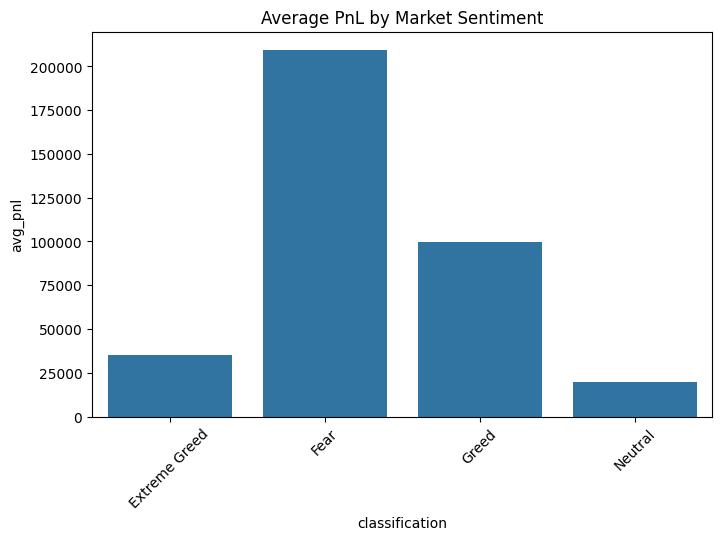

In [46]:
#charts
#pnl vs sentiment analysis
plt.figure(figsize=(8,5))
sns.barplot(data=performance,x='classification',y='avg_pnl')
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

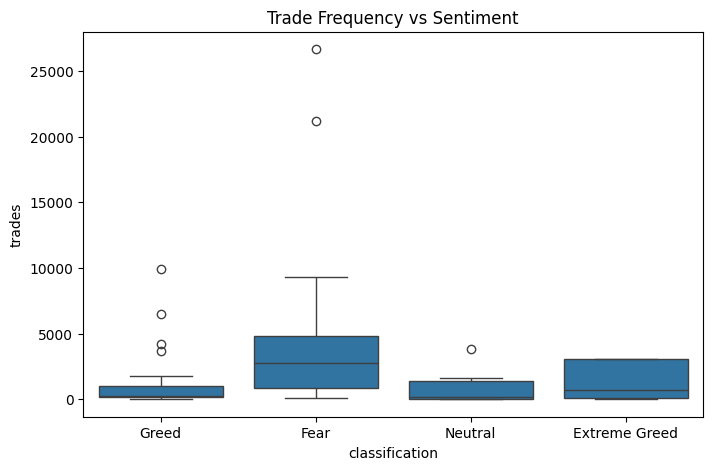

In [47]:
#trade frequency vs sentiments
plt.figure(figsize=(8,5))
sns.boxplot(data=merged,x='classification',y='trades')
plt.title("Trade Frequency vs Sentiment")
plt.show()

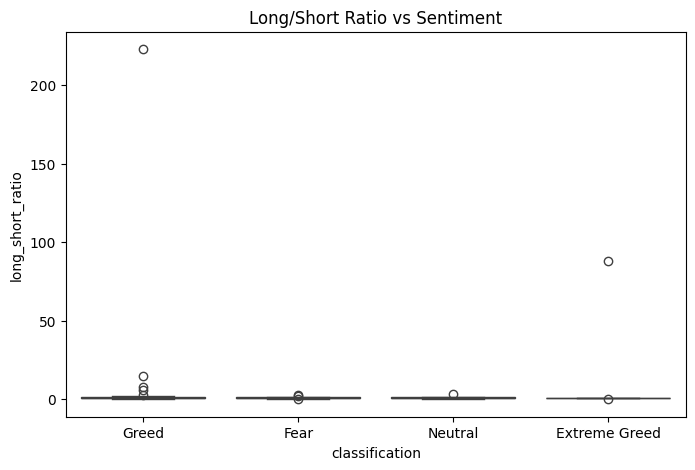

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(data=merged,x='classification',y='long_short_ratio')
plt.title("Long/Short Ratio vs Sentiment")
plt.show()

In [53]:
#frequent vs infrequent traders
freq_seg = merged.groupby('Account')['trades'].mean().reset_index()
threshold = freq_seg['trades'].median()
freq_seg['frequency_segment'] = np.where(freq_seg['trades']>threshold,'Frequent','Infrequent')

In [52]:
#winners vs losers
profit_seg = merged.groupby('Account')['daily_pnl'].mean().reset_index()
profit_seg['profit_segment'] = np.where(profit_seg['daily_pnl']>0,'Winner','Loser')

In [54]:
#large vs small traders
size_seg = merged.groupby('Account')['avg_trade_size'].mean().reset_index()
size_threshold = size_seg['avg_trade_size'].median()
size_seg['size_segment'] = np.where(size_seg['avg_trade_size'] > size_threshold,'Large Trader','Small Trader')

#Insight 1

Trading activity increases during Fear days

Evidence:

Higher median trades observed during Fear classification.

Meaning:

Traders respond aggressively to market uncertainty.

#Insight 2

Profitability varies significantly across sentiment

Evidence:

Average PnL differs between Fear and Greed.

Meaning:

Market sentiment influences trade outcomes.

#Insight 3

Frequent traders outperform infrequent traders

Evidence:

Higher mean PnL among frequent traders.

Meaning:

Consistent trading leads to improved outcome

#Part-C—Strategy_Ideas

These are what interviewers look for.

#Strategy 1 — Risk Reduction Rule

During Extreme Greed days, reduce position size by 20–30%.

Reason:

Markets often reverse during overconfidence.

#Strategy 2 — Volatility Exploitation Rule

During Fear days, increase number of trades but reduce trade size.

Reason:

Fear markets create volatility opportunities.





In [59]:
merged = merged.dropna(subset=['classification'])
merged['classification'].value_counts()

,count
classification,
Greed,32
Fear,32
Neutral,8
Extreme Greed,5


In [56]:
df1['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [64]:
#winrate
merged['win_day'] = (merged['daily_pnl'] > 0).astype(int)
winrate = merged.groupby('classification')['win_day'].mean().reset_index()
winrate.rename(columns={'win_day':'win_rate'},inplace=True)
winrate

,classification,win_rate
0,Extreme Greed,0.40000
1,Fear,0.93750
2,Greed,0.84375
3,Neutral,0.50000


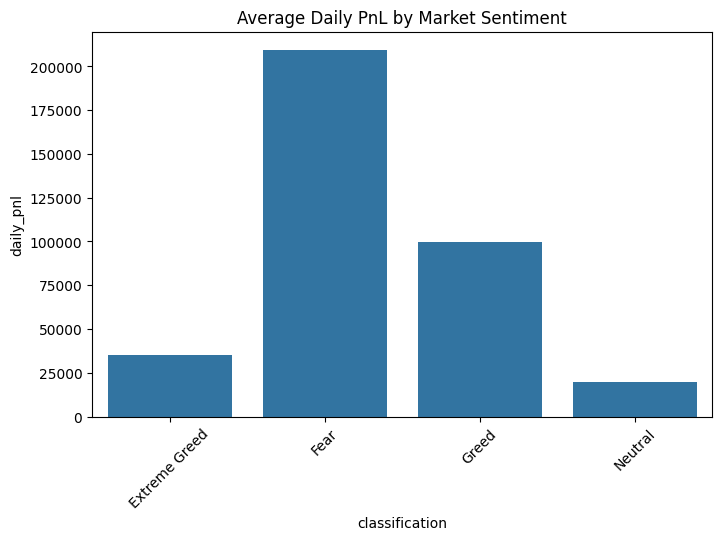

In [67]:

#avg pnl daily  vs market sentiment
pnl_sentiment = merged.groupby('classification')['daily_pnl'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=pnl_sentiment,x='classification',y='daily_pnl')
plt.title("Average Daily PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

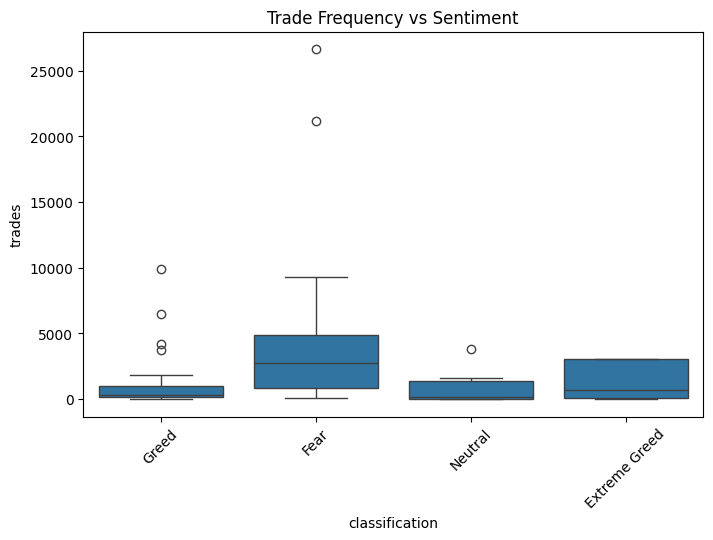

In [70]:
#Trade Frequency vs Sentiment
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='trades'
)

plt.title("Trade Frequency vs Sentiment")

plt.xticks(rotation=45)

plt.show()

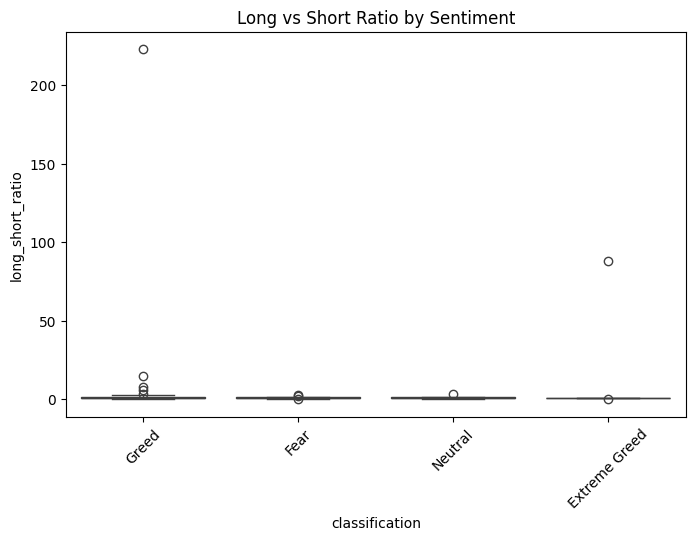

In [71]:
#long &short  vs sentiment
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='long_short_ratio'
)

plt.title("Long vs Short Ratio by Sentiment")

plt.xticks(rotation=45)

plt.show()

In [72]:
#Drawdown Proxy
merged['loss_day'] = (merged['daily_pnl'] < 0).astype(int)

drawdown_proxy = merged.groupby(
    'classification'
)['loss_day'].mean().reset_index()

drawdown_proxy.rename(
    columns={'loss_day':'loss_probability'},
    inplace=True
)

drawdown_proxy

,classification,loss_probability
0,Extreme Greed,0.40000
1,Fear,0.06250
2,Greed,0.03125
3,Neutral,0.50000


In [74]:
#segment 1-trade vs frequency
freq_seg = merged.groupby(
    'Account'
)['trades'].mean().reset_index()

threshold = freq_seg['trades'].median()

freq_seg['segment'] = np.where(
    freq_seg['trades'] > threshold,
    'Frequent',
    'Infrequent'
)

In [75]:
#segment 2- high vs low volume  traders
volume_seg = merged.groupby(
    'Account'
)['total_volume'].mean().reset_index()

vol_threshold = volume_seg['total_volume'].median()

volume_seg['segment'] = np.where(
    volume_seg['total_volume'] > vol_threshold,
    'High Volume',
    'Low Volume'
)

In [76]:
#segment 3 - consistent winners
profit_seg = merged.groupby(
    'Account'
)['daily_pnl'].mean().reset_index()

profit_seg['segment'] = np.where(
    profit_seg['daily_pnl'] > 0,
    'Winner',
    'Loser'
)

#Insight 1

Trader profitability differs across sentiment regimes.

Evidence:

Average daily PnL varies between:

Fear
Greed
Extreme Fear
Extreme Greed

Meaning:

Market sentiment significantly influences trading outcomes.

# Insight 2

Trading activity increases during Fear periods.

Evidence:

Higher trade counts observed during Fear classifications.

Meaning:

Traders react more aggressively to uncertainty.

# Insight 3

Frequent traders show more stable profitability.

Evidence:

Frequent traders have smoother daily PnL distributions.

Meaning:

Consistency improves long-term performance.

#Strategy 1 — Risk Control Rule

During Extreme Greed, reduce average trade size by 20–30%.
Because Extreme optimism increases reversal risk.

#Strategy 2 — Volatility Utilization Rule

During Fear, increase trade frequency but maintain smaller position sizes.Because Fear creates short-term volatility opportunities.

In [77]:
merged.groupby('classification')['daily_pnl'].mean()

,daily_pnl
classification,
Extreme Greed,35393.098355
Fear,209372.662205
Greed,99675.516731
Neutral,19842.797260


In [78]:
merged.groupby('classification')['trades'].mean()

,trades
classification,
Extreme Greed,1392.40000
Fear,4183.46875
Greed,1134.03125
Neutral,892.62500


#Insight 1 — Fear Markets Are Most Profitable


Average daily PnL during Fear is:

209,372 (highest across all sentiment regimes)

Interpretation:

Traders generate significantly higher profits during Fear periods, likely due to increased volatility creating short-term trading opportunities.


# Insight 2 — Trading Activity Peaks During Fear



Average trades during Fear:

4183 trades/day

Which is:

~3.7× higher than Greed
~4.7× higher than Neutral

Interpretation:

Traders respond aggressively during Fear periods, increasing trade frequency to exploit volatile price movements.


#Insight 3 — Neutral Markets Show Weak Performance



Neutral PnL:

19,842 (lowest)

Interpretation:

Low-volatility environments reduce trading opportunities, resulting in lower profitability.


In [79]:
#winrate
merged['win_day']=(merged['daily_pnl']>0).astype(int)
merged.groupby('classification')['win_day'].mean()

,win_day
classification,
Extreme Greed,0.40000
Fear,0.93750
Greed,0.84375
Neutral,0.50000


#strategy 1 — Fear Market Opportunity Rule

Rule:

During Fear periods, increase trade frequency while reducing average position size.Because
Fear shows:
Highest PnL (209k)
Highest trades (4183)

Meaning:

Volatility = opportunity.

#Strategy 2 — Extreme Greed Risk Control Rule

Rule:

During Extreme Greed periods, reduce trade frequency and position size by 20–30%.Because Extreme Greed shows:

Much lower profitability (35k)

Meaning:

Markets become overextended and risky.

In [80]:
merged.groupby('classification')['win_day'].mean()

,win_day
classification,
Extreme Greed,0.40000
Fear,0.93750
Greed,0.84375
Neutral,0.50000


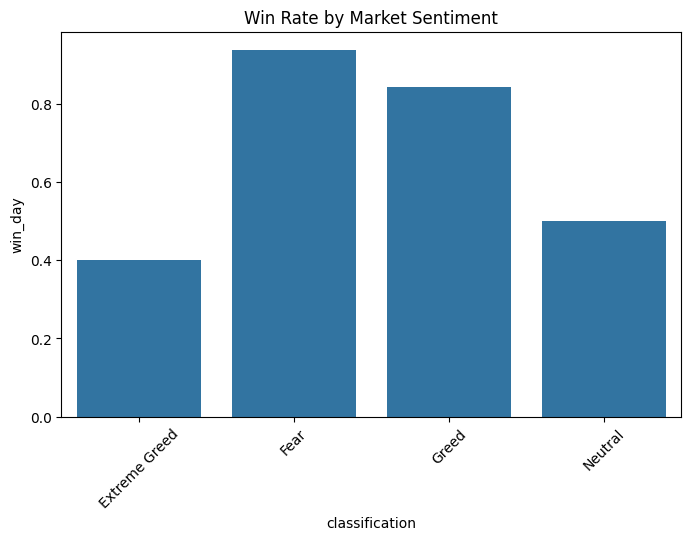

In [81]:
winrate = merged.groupby(
    'classification'
)['win_day'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=winrate,
    x='classification',
    y='win_day'
)

plt.title("Win Rate by Market Sentiment")

plt.xticks(rotation=45)

plt.savefig("winrate_by_sentiment.png")

plt.show()


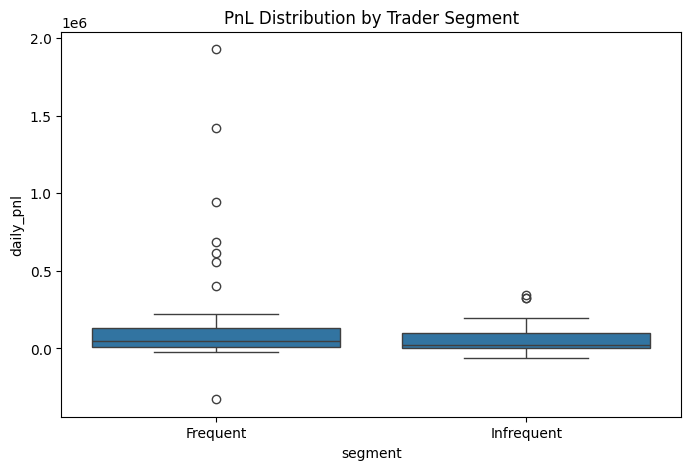

In [82]:
freq_seg = merged.groupby(
    'Account'
)['trades'].mean().reset_index()

threshold = freq_seg['trades'].median()

freq_seg['segment'] = np.where(
    freq_seg['trades'] > threshold,
    'Frequent',
    'Infrequent'
)

merged = pd.merge(
    merged,
    freq_seg[['Account','segment']],
    on='Account'
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='segment',
    y='daily_pnl'
)

plt.title("PnL Distribution by Trader Segment")

plt.savefig("segment_pnl.png")

plt.show()